<a href="https://colab.research.google.com/github/MUKESHKUMAR-21/DeepLearning/blob/main/DL_Exp05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda


100%|██████████| 170M/170M [41:45<00:00, 68.0kB/s]



Extracting features using pre-trained VGG backbone...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 182MB/s]


Training classifier head for VGG...
Epoch 01 -> Train Acc: 41.75%, Val Acc: 66.00%
Epoch 02 -> Train Acc: 93.75%, Val Acc: 65.00%
Epoch 04 -> Train Acc: 100.00%, Val Acc: 60.00%
Epoch 06 -> Train Acc: 100.00%, Val Acc: 62.00%
Epoch 08 -> Train Acc: 100.00%, Val Acc: 63.00%
Epoch 10 -> Train Acc: 100.00%, Val Acc: 64.00%

Extracting features using pre-trained RESNET backbone...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 225MB/s]


Training classifier head for RESNET...
Epoch 01 -> Train Acc: 15.25%, Val Acc: 19.00%
Epoch 02 -> Train Acc: 35.00%, Val Acc: 34.00%
Epoch 04 -> Train Acc: 64.50%, Val Acc: 54.00%
Epoch 06 -> Train Acc: 81.00%, Val Acc: 61.00%
Epoch 08 -> Train Acc: 87.00%, Val Acc: 69.00%
Epoch 10 -> Train Acc: 88.75%, Val Acc: 72.00%

Extracting features using pre-trained GOOGLENET backbone...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 177MB/s]


Training classifier head for GOOGLENET...
Epoch 01 -> Train Acc: 14.50%, Val Acc: 22.00%
Epoch 02 -> Train Acc: 48.50%, Val Acc: 47.00%
Epoch 04 -> Train Acc: 65.75%, Val Acc: 58.00%
Epoch 06 -> Train Acc: 78.75%, Val Acc: 61.00%
Epoch 08 -> Train Acc: 81.25%, Val Acc: 61.00%
Epoch 10 -> Train Acc: 85.25%, Val Acc: 62.00%

Final Performance Summary (Validation Accuracy):
VGG        : 64.00%
RESNET     : 72.00%
GOOGLENET  : 62.00%


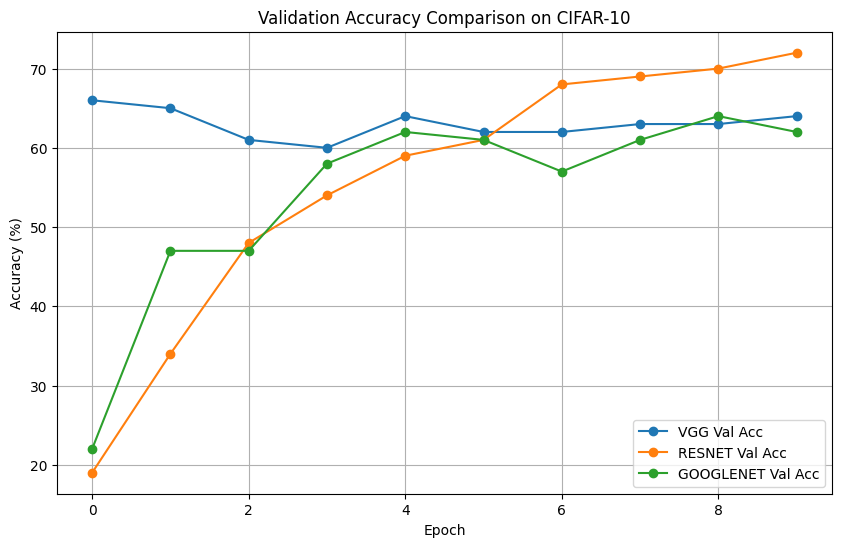

In [14]:
import os
import tarfile
import urllib.request
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Bypassing the dataset loading bottleneck
# ----------------------------------------------------
os.makedirs('./data', exist_ok=True)
tar_path = './data/cifar-10-python.tar.gz'
expected_folder = './data/cifar-10-batches-py'

# If the folder doesn't exist but a corrupt/partial archive exists, delete it first
if not os.path.exists(expected_folder):
    if os.path.exists(tar_path):
        try:
            print("Verifying existing archive...")
            with tarfile.open(tar_path, "r:gz") as tar:
                tar.getmembers()
        except Exception:
            print("Corrupt archive detected. Removing it to redownload...")
            os.remove(tar_path)

    if not os.path.exists(tar_path):
        print("Downloading CIFAR-10 archive from the official mirror...")
        url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
        urllib.request.urlretrieve(url, tar_path)
        print("Download complete.")

    print("Extracting archive file...")
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path='./data')
        print("Extraction complete.")
    except Exception as e:
        print(f"Extraction failed: {e}. Please manually delete '{tar_path}' and try again.")

# ----------------------------------------------------
# Ultra-Fast Feature-Extraction Pipeline
# ----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Enabled download=True to automatically handle integrity checks and verification
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
subset_dataset = Subset(full_train_dataset, range(500))

data_loader = DataLoader(subset_dataset, batch_size=500, shuffle=False, num_workers=0)
all_images, all_labels = next(iter(data_loader))
all_images, all_labels = all_images.to(device), all_labels.to(device)

def get_backbone_and_features(name, images):
    if name == "vgg":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
        backbone = model.features
        pool = nn.AdaptiveAvgPool2d((7, 7))
        backbone.eval()
        with torch.no_grad():
            features = pool(backbone(images))
            features = torch.flatten(features, 1)
        return features, 25088

    elif name == "resnet":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
        backbone = nn.Sequential(*list(model.children())[:-1])
        backbone.eval()
        with torch.no_grad():
            features = torch.flatten(backbone(images), 1)
        return features, 512

    elif name == "googlenet":
        model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT).to(device)
        backbone = nn.Sequential(*list(model.children())[:-1])
        backbone.eval()
        with torch.no_grad():
            features = torch.flatten(backbone(images), 1)
        return features, 1024

models_list = ["vgg", "resnet", "googlenet"]
results = {}
val_accs_history = {}

for model_name in models_list:
    print(f"\nExtracting features using pre-trained {model_name.upper()} backbone...")
    features, input_dim = get_backbone_and_features(model_name, all_images)

    train_features, val_features = features[:400], features[400:]
    train_labels, val_labels = all_labels[:400], all_labels[400:]

    train_loader = DataLoader(TensorDataset(train_features, train_labels), batch_size=64, shuffle=True)
    val_loader = DataLoader(TensorDataset(val_features, val_labels), batch_size=64, shuffle=False)

    classifier = nn.Linear(input_dim, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=1e-3)

    print(f"Training classifier head for {model_name.upper()}...")
    val_history = []
    for epoch in range(10):
        classifier.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad(set_to_none=True)
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_acc = 100 * correct / total

        classifier.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = classifier(inputs)
                _, predicted = outputs.max(1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        val_history.append(val_acc)

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d} -> Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    results[model_name] = val_acc
    val_accs_history[model_name] = val_history

print("\nFinal Performance Summary (Validation Accuracy):")
for name, acc in results.items():
    print(f"{name.upper():<10} : {acc:.2f}%")

# ----------------------------------------------------
# Visualization of results
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
for name, history in val_accs_history.items():
    plt.plot(history, marker='o', label=f'{name.upper()} Val Acc')
plt.title('Validation Accuracy Comparison on CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()